天气 湿度 是否玩高尔夫球
晴天  高       否
晴天  高       否
晴天  高       是
多云  高       是
多云 正常       是
下雨  高       否
下雨 正常       是
下雨 正常       是
晴天 正常       是
晴天 正常       是
多云  高       是
多云 正常       是
下雨  高       否
下雨 正常       是


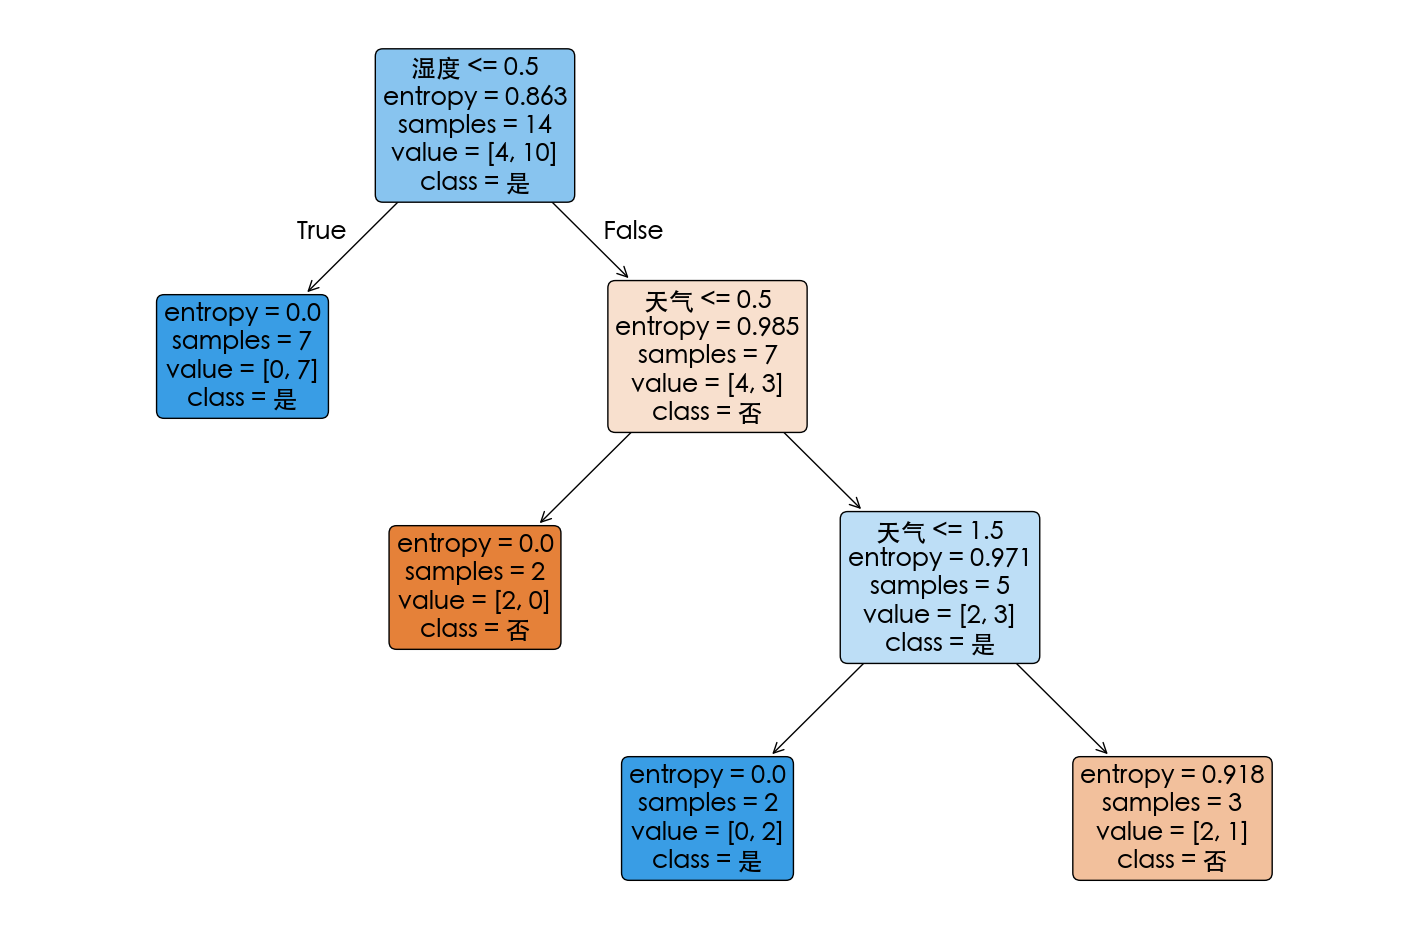

决策树文本结构:
|--- 湿度 <= 0.50
|   |--- class: 是
|--- 湿度 >  0.50
|   |--- 天气 <= 0.50
|   |   |--- class: 否
|   |--- 天气 >  0.50
|   |   |--- 天气 <= 1.50
|   |   |   |--- class: 是
|   |   |--- 天气 >  1.50
|   |   |   |--- class: 否

预测结果:
天气: 晴天, 湿度: 高 → 否
天气: 晴天, 湿度: 正常 → 是
天气: 多云, 湿度: 高 → 是
天气: 多云, 湿度: 正常 → 是
天气: 下雨, 湿度: 高 → 否
天气: 下雨, 湿度: 正常 → 是


In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from sklearn.tree import plot_tree
from sklearn.tree import export_text
from matplotlib.text import Text

# 配置 matplotlib 使用字体
rcParams['font.sans-serif'] = ['Heiti TC']
rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 创建数据集
data = {
    '天气': ['晴天', '晴天', '晴天', '多云', '多云', '下雨', '下雨', '下雨', '晴天', '晴天', '多云', '多云', '下雨', '下雨'],
    '湿度': ['高', '高', '高', '高', '正常', '高', '正常', '正常', '正常', '正常', '高', '正常', '高', '正常'],
    '是否玩高尔夫球': ['否', '否', '是', '是', '是', '否', '是', '是', '是', '是', '是', '是', '否', '是']
}

# 将数据转换为 DataFrame
df = pd.DataFrame(data)

print(df.to_string(index=False))

# 对特征进行编码
le_weather = LabelEncoder()
le_humidity = LabelEncoder()
df['天气_encoded'] = le_weather.fit_transform(df['天气'])
df['湿度_encoded'] = le_humidity.fit_transform(df['湿度'])

# 特征和目标变量
X = df[['天气_encoded', '湿度_encoded']]  # 确保 X 是一个 DataFrame
y = df['是否玩高尔夫球']

# 创建决策树分类器
clf = DecisionTreeClassifier(criterion='entropy', random_state=42)

# 训练模型
clf.fit(X, y)

# 打印决策树的结构
plt.figure(figsize=(18, 12))
tree_plot = plot_tree(clf, feature_names=['天气', '湿度'], class_names=['否', '是'], filled=True, rounded=True)
# 遍历图中的每个文本元素并调整字体大小
for t in plt.gca().get_children():
    if isinstance(t, Text):
        t.set_fontsize(18)  # 设置字体大小为 10
plt.show()

# 通过文本打印决策树
tree_rules = export_text(clf, feature_names=['天气', '湿度'])
print("决策树文本结构:")
print(tree_rules)

# 预测新样本
new_samples = [
    [le_weather.transform(['晴天'])[0], le_humidity.transform(['高'])[0]],  # 晴天, 高
    [le_weather.transform(['晴天'])[0], le_humidity.transform(['正常'])[0]],  # 晴天, 正常
    [le_weather.transform(['多云'])[0], le_humidity.transform(['高'])[0]],  # 多云, 高
    [le_weather.transform(['多云'])[0], le_humidity.transform(['正常'])[0]],  # 多云, 正常
    [le_weather.transform(['下雨'])[0], le_humidity.transform(['高'])[0]],  # 下雨, 高
    [le_weather.transform(['下雨'])[0], le_humidity.transform(['正常'])[0]]  # 下雨, 正常
]

# 将 new_samples 转换为 DataFrame，并设置列名
new_samples_df = pd.DataFrame(new_samples, columns=['天气_encoded', '湿度_encoded'])

# 使用 DataFrame 进行预测
predictions = clf.predict(new_samples_df)
print("预测结果:")
for sample, prediction in zip(new_samples, predictions):
    print(f"天气: {le_weather.inverse_transform([sample[0]])[0]}, 湿度: {le_humidity.inverse_transform([sample[1]])[0]} → {prediction}")